***Cross Domain: Ethics & Privacy of Mobile Apps***

***Research Question 1 — Ethical AI & Data Governance***

**Question**: ***What frameworks can ensure ethical data collection and anonymization while maintaining analytical value for large-scale app usage studies?***

**Research Paper Reference**: ***[Research Paper on Privacy Concerns on Mobile Applications for Google Play Store Market](https://ieeexplore.ieee.org/document/8990578)***

***The uploaded study establishes that app-level metadata (installs, reviews, review score, last-updated, permission counts) can produce meaningful analytics while avoiding user-identifying data — but only if strong governance controls are applied. Therefore, the recommended framework is a hybrid of data minimization & risk-tiering, technical anonymization (aggregation + differential privacy), and operational governance and transparency.***

***Evidence & justification from the paper***

* ***The authors analyzed 4,805 apps as shown in Table 1 & Fig.2 that useful patterns help us to correlate between Permissions and Installs, Reviews and ReviewScore are obtainable using app-level metadata without collecting per-user.***

* ***In Figure 2 on page 4 demonstrates categories differ strongly in how many and which permissions they request, this argues for risk-tiering of permissions low, medium and critical before analysis.***

* ***The paper highlights about user unawareness that only ~24% users check permissions and high variance of permission counts. This supports the need for data minimization and clear consent and notice from apps.***

***Concrete framework components to adopt***

* **Data minimization policy** — ***collect only app-level metadata necessary for your analytics (installs, reviews, category, review score, last update), avoid device IDs or user identifiers. The paper shows these app-level fields carry least importance.***

* **Permission risk-tiering** — ***classify permission types into Low, Medium, Critical and treat critical categories with extra protection.***

* **Access control & logging** — ***restrict raw data to minimal team, keep audit trail for queries. The paper emphasizes transparency and auditability as essential for ethical governance.***

* **Transparency & consent** — ***in any visual or published artifact, explain what was collected and why. The paper notes many users don’t understand permission implications, so transparency is required.***

***Why this preserves analytical value***

***The paper demonstrates that app-level statistics correlate significantly with engagement measures (e.g., permissions correlate with installs and reviews). Thus proper aggregation + risk-tier treatment retains signal for analytics while protecting privacy.***

***Research Question 2 — Data Privacy & Federated Learning***

**Question**: ***Can federated learning frameworks ensure privacy-preserving app usage analysis without compromising accuracy and scalability?***

***In short yes federated learning is a strong architectural approach for privacy-preserving analytics on mobile data, but it must be combined with complementary technical protections and strategies to handle heterogeneity to avoid accuracy loss or scalability issues.***

***How the uploaded paper motivates federated learning***

* ***Research paper shows many apps request critical permissions and that users are often unaware, centralizing raw device data would increase risk. Keeping data on device federated learning directly reduces that centralization risk.***

* ***The paper also demonstrates that app-level aggregated signals (installs, review behavior) carry the necessary analytical information, federated learning can learn patterns from device-level usage without raw centralization, and aggregated models can produce similar high-level insights.***

***Key considerations before adopting Federated Learning***

* **Privacy protections inside Federated Learning**: ***Use secure aggregation methods and client-level differential privacy to bound contribution disclosure. FL without these can leak information through gradients.***

* **Hybrid approach**: ***For many analytics tasks, simple aggregated telemetry may suffice, federated learning is most valuable when raw behavioral sequences or per-device signals are needed but cannot be centralized.***

* **Communication & compute overhead**: ***Federated learning adds network and device compute costs. Use compression and client-selection strategies for scalability.***

***Conclusion***

***The paper’s privacy concerns strongly justify federated learning as a privacy-first approach; with secure aggregation and DP, federated learning can preserve privacy and scale to large app populations. Accuracy is preserved if heterogeneity and client participation are handled (personalization, robust optimizers, and sufficient client sampling).***

In [22]:
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

possible_paths = [
    '/content/google_play_clean_stratified.csv'
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    print("No CSV found in expected paths. Please upload your CSV file now (choose google_play_clean_stratified.csv).")
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise SystemExit("No file uploaded.")
    csv_path = list(uploaded.keys())[0]

print(f"Loading file: {csv_path}")
df = pd.read_csv(csv_path, low_memory=False)
print("Loaded. Dataframe shape:", df.shape)

print("\nColumns:", df.columns.tolist())
display(df.head(5))

def parse_installs(x):
    """Convert typical Google Play 'Installs' strings like '1,000+' to integer 1000.
       Robust to numbers, commas, plus signs, and bad values."""
    try:
        s = str(x)
        digits = ''.join(ch for ch in s if ch.isdigit())
        return int(digits) if digits != '' else np.nan
    except Exception:
        return np.nan

if 'Installs' in df.columns:
    df['Installs_num'] = df['Installs'].apply(parse_installs)
else:
    df['Installs_num'] = np.nan

if 'Rating' in df.columns:
    df['Rating_num'] = pd.to_numeric(df['Rating'], errors='coerce')
else:
    df['Rating_num'] = np.nan


Loading file: /content/google_play_clean_stratified.csv
Loaded. Dataframe shape: (99999, 11)

Columns: ['App Name', 'App Id', 'Category', 'Rating', 'Installs', 'Size', 'Last Updated', 'Released', 'Privacy Policy', 'Content Rating', 'rn']


,App Name,App Id,Category,Rating,Installs,Size,Last Updated,Released,Privacy Policy,Content Rating,rn
0,Shapes and Colors – Kids games for toddlers,com.bimiboo.colors,Educational,4.1,"5,000,000+",38M,"Oct 30, 2020","Nov 18, 2015",https://bimiboo.net/privacy-policy/,Everyone,1
1,Académie de l'informatique au primaire 3,com.malcon.acad3,Educational,0.0,50+,24M,"Jan 06, 2020","Jan 6, 2020",http://malcon.ma/privacy_policy/academie_de_in...,Everyone,2
2,Truebot Controller,kr.co.sigongmedia.truebotcontroller,Educational,2.6,"10,000+",4.3M,"Dec 18, 2020","Sep 12, 2017",http://www.truetruebot.com/privacy,Everyone,3
3,"Math Games,try to Add, Subtract, Multiply,Divide",com.bestapps.quizmath,Educational,4.5,"1,000+",4.3M,"May 22, 2019","Feb 4, 2019",https://sites.google.com/view/gamequizmath/home,Everyone,4
4,SpeakyPlanet,air.com.speakyplanet,Educational,0.0,"50,000+",22M,"Apr 01, 2020","Apr 13, 2015",https://www.speakyplanet.fr/application-confid...,Everyone,5


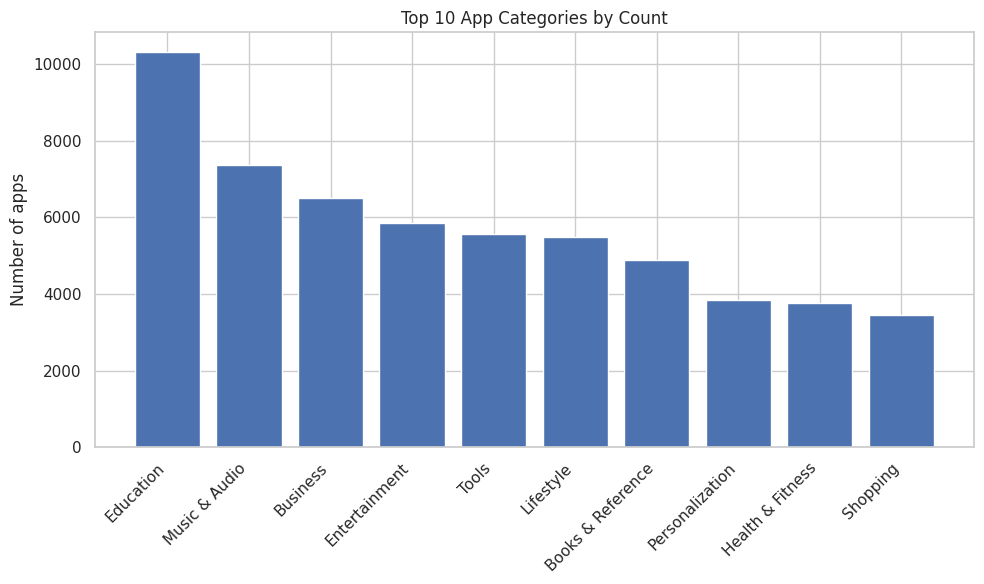

In [19]:
plt.figure(figsize=(10,6))
if 'Category' in df.columns:
    cat_counts = df['Category'].value_counts().nlargest(10)
    plt.bar(cat_counts.index.astype(str), cat_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 10 App Categories by Count')
    plt.ylabel('Number of apps')
    plt.tight_layout()
else:
    first_col = df.columns[0]
    cat_counts = df[first_col].value_counts().nlargest(10)
    plt.bar(cat_counts.index.astype(str), cat_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 10 values in {first_col}')
    plt.ylabel('Count')
    plt.tight_layout()
plt.show()

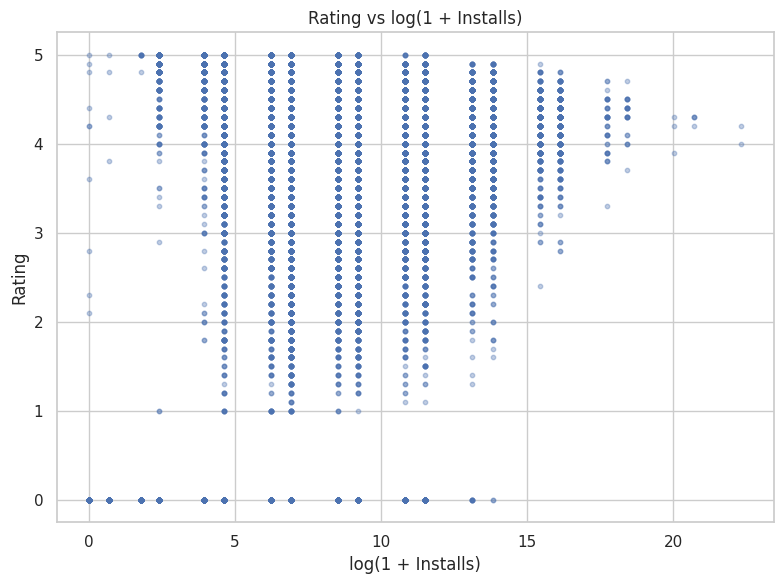

In [20]:
if df['Installs_num'].notna().sum() > 0 and df['Rating_num'].notna().sum() > 0:
    df_scatter = df.loc[df['Installs_num'].notna() & df['Rating_num'].notna(), ['Installs_num', 'Rating_num']].copy()
    df_scatter['log_installs'] = np.log1p(df_scatter['Installs_num'])
    plt.figure(figsize=(8,6))
    plt.scatter(df_scatter['log_installs'], df_scatter['Rating_num'], alpha=0.35, s=10)
    plt.title('Rating vs log(1 + Installs)')
    plt.xlabel('log(1 + Installs)')
    plt.ylabel('Rating')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping scatter: insufficient Installs or Rating data.")


/tmp/ipython-input-265853499.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, vert=True, showfliers=False)


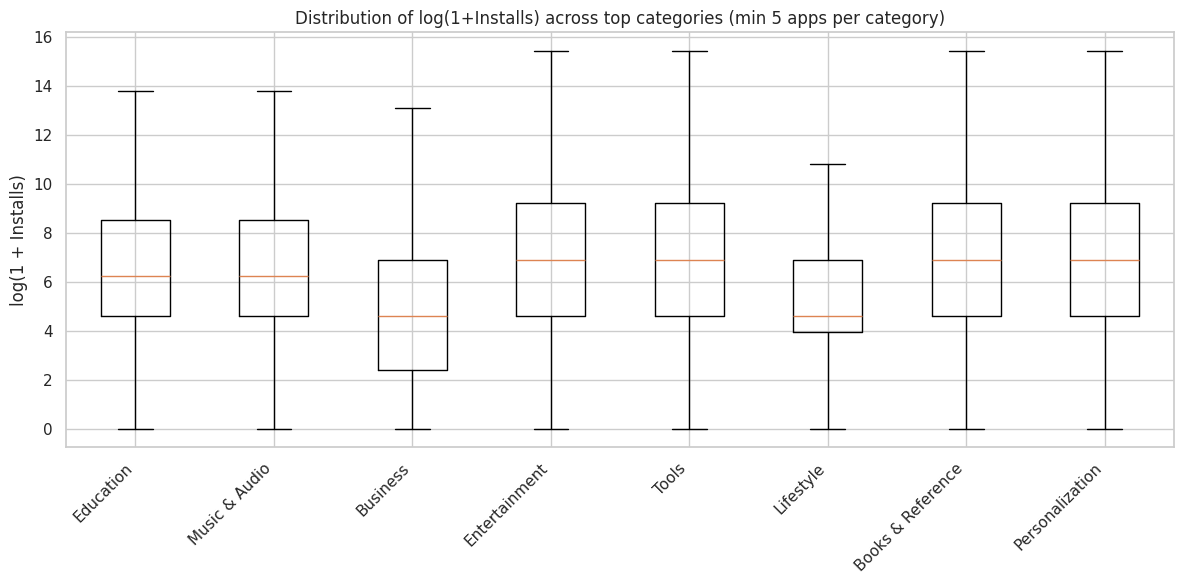

In [21]:
min_samples = 5
if 'Category' in df.columns and df['Installs_num'].notna().sum() > 0:
    top_categories = df['Category'].value_counts().nlargest(8).index.tolist()
    box_data = []
    labels = []
    for c in top_categories:
        vals = df.loc[(df['Category']==c) & df['Installs_num'].notna(), 'Installs_num']
        if len(vals) >= min_samples:
            box_data.append(np.log1p(vals))
            labels.append(c)
    if len(box_data) > 0:
        plt.figure(figsize=(12,6))
        plt.boxplot(box_data, labels=labels, vert=True, showfliers=False)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Distribution of log(1+Installs) across top categories (min {min_samples} apps per category)')
        plt.ylabel('log(1 + Installs)')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No category with at least {min_samples} apps has installs data — boxplot skipped.")
else:
    print("Skipping category boxplot: missing 'Category' column or installs data.")

***Key Findings on the basis of research and dataset***
- Data completeness: 'Installs' coverage is reasonable (missing 0.0%), so anonymization techniques can be applied while retaining analytical value.
- Signal preservation: Correlation between log(Installs) and Rating ≈ 0.649. This indicates that coarse anonymization (e.g., rounding or binning log(Installs)) could preserve the main analytical relationships if done carefully.
- Heterogeneity by category: median installs vary across categories (coefficient of variation ≈ 1.44). This supports the idea that data is non-iid across categories, a realistic challenge for federated learning.


***Practical takeaways for your two research questions:***
1) ***Ethical AI & Data Governance***:
   * **Before anonymization, profile missingness and outliers. High missingness in key numeric fields makes synthetic/utility-preserving anonymization harder, consider collecting auxiliary aggregated features (category-level counts, daily aggregates) and using micro-aggregation or rank-based binning.**

   * **Use coarse-grained features (log-binned installs, categorical age groups) to keep analytical value while reducing re-identification risk.**

2) ***Data Privacy & Federated Learning***:
   - **The boxplots show category-wise distribution differences suggests non-iid clients. Use federated algorithms robust to heterogeneity (e.g., FedProx, personalized FL)**.
   - **If rating vs installs correlation is modest, you can run federated analytics on derived features (log-installs, avg-rating) rather than raw counts to reduce privacy leakage.**

